In [2]:
import tensorflow as tf
import numpy as np
import pickle
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from google.colab import files
import matplotlib.pyplot as plt

# --- Upload model and pkl file ---
uploaded = files.upload()  # Upload cropcare_model.h5 and class_labels.pkl
uploaded = files.upload()


Saving class_labels.pkl to class_labels (1).pkl


Saving cropcare_final.h5 to cropcare_final.h5


Upload an image to predict:


Saving bact_spot_img.jpg to bact_spot_img.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

✅ Predicted class: Strawberry___Leaf_scorch


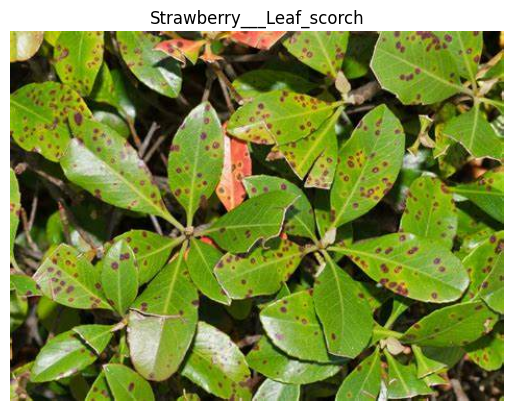

In [3]:
# --- Load the model ---
model = tf.keras.models.load_model('cropcare_final.h5')

# --- Load class labels from .pkl file ---
with open('class_labels.pkl', 'rb') as f:
    labels = pickle.load(f)

# --- Upload image to predict ---
print("Upload an image to predict:")
image_upload = files.upload()
img_path = list(image_upload.keys())[0]

# --- Preprocess the image ---
img = load_img(img_path, target_size=(128, 128))  # Resize as per model input
img_array = img_to_array(img)
img_array = preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

# --- Predict ---
pred = model.predict(img_array)
predicted_class_index = np.argmax(pred)
predicted_label = labels[predicted_class_index]

# --- Output ---
print(f"\n✅ Predicted class: {predicted_label}")

# --- Show the image ---
plt.imshow(load_img(img_path))
plt.axis('off')
plt.title(predicted_label)
plt.show()
